## Use minimum cost flow method to assign targets with 3 tiles. One tile has overlap with the others. --04-5-2026

In [1]:
import os, sys, fitsio
import numpy as np
import astropy.units as u
from network_flow import *
from astropy.table import Table, vstack
# import networkx as nx
import multiprocessing
import matplotlib.pyplot as plt

Patrol radius: 0.013021 degrees
Collision separation: 15.625 arcsec = 0.004340 deg = 2.000 mm
Number of fibers: 2184
488829.0354408155
Total # of unique galaxies in tiles:  7361
There are 6312 paired fibers in one tile


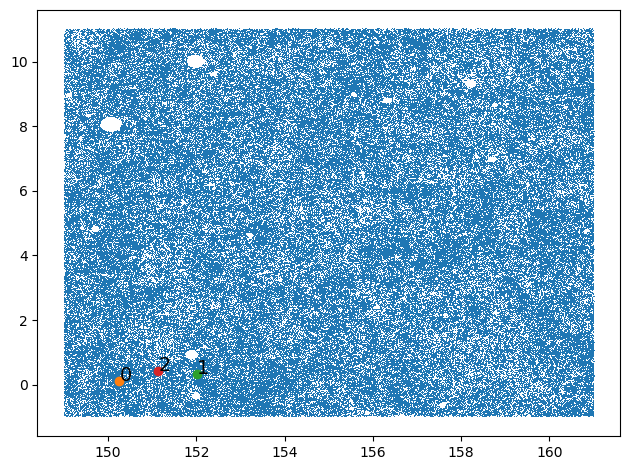

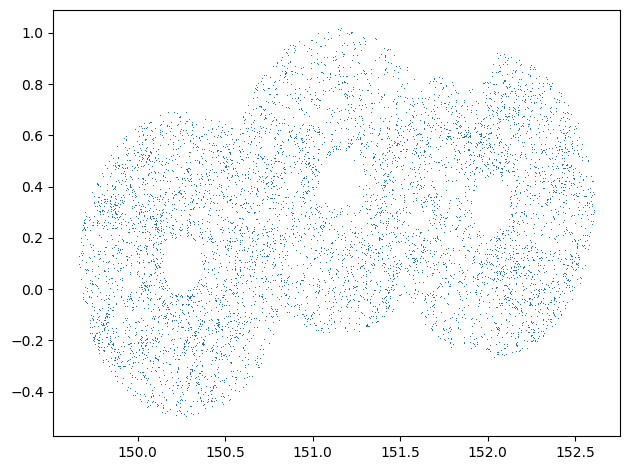

In [2]:
# Constants
TILE_INNER_RADIUS_DEG = 0.1085       # Tile inner radius in degrees
TILE_OUTER_RADIUS_DEG = 0.5968       # Tile outer radius in degrees

platescale = 128   # um/arcsec
r_patrol = 6.0     # mm, radius of circle that one fiber could reach 
r_patrol_deg = r_patrol * 1.e3 / platescale / 3600
print(f"Patrol radius: {r_patrol_deg:.6f} degrees")

COLLISION_SEPARATION_ARCSEC = 15.625  # Fiber collision separation in arcsec, corresponding to 2mm on focalplane
COLLISION_SEPARATION_DEG = COLLISION_SEPARATION_ARCSEC / 3600.0
COLLISION_SEPARATION_MM = COLLISION_SEPARATION_ARCSEC * platescale / 1000.0
print(f"Collision separation: {COLLISION_SEPARATION_ARCSEC} arcsec = {COLLISION_SEPARATION_DEG:.6f} deg = {COLLISION_SEPARATION_MM:.3f} mm")

# Get fiber positions and set random seed
fiberpos_xy = get_fiberpos()
N_fibers = fiberpos_xy.shape[0]
print(f"Number of fibers: {N_fibers}")

np.random.seed(23)

rmagcut = 20.5

ifile = f"../input/gal_DR9_rmag{rmagcut}_149.0ra161.0_-1.0dec11.0.fits"
gal_cat = fitsio.read(ifile, columns=['gal_id', 'RA', 'DEC', 'z'])
gal_cat = Table(gal_cat)

# assign (1, 2) range priority 
gal_cat['priority'] = 1.0 + np.random.rand(len(gal_cat))

ifile = "./output/tile_final_positions.txt"
tiles_ra, tiles_dec = np.loadtxt(ifile, unpack=True)

Ntiles = 3
tiles_ra = tiles_ra[0: Ntiles]
tiles_dec = tiles_dec[0: Ntiles]
print(np.sum(gal_cat['priority']))

tiles_dec[2] -= 0.8  # to make tile 2 have some overlap with tile_0 and 1

fig, ax = plt.subplots(dpi=100)
ax.plot(gal_cat['RA'], gal_cat['DEC'], ',')
i = 0
for tile_ra, tile_dec in zip(tiles_ra, tiles_dec):
    ax.plot(tile_ra, tile_dec, 'o')
    ax.text(tile_ra, tile_dec, i, fontsize=14)
    i += 1
plt.tight_layout()

## find all galaxies in a given set of tiles
gal_in_tiles = []
for tile_ra, tile_dec in zip(tiles_ra, tiles_dec):
    mask = find_targets_in_tile(tile_ra, tile_dec, gal_cat['RA'], gal_cat['DEC'], TILE_INNER_RADIUS_DEG, TILE_OUTER_RADIUS_DEG)

    gal_in_tiles.append(gal_cat[mask])
    
gal_in_tiles = vstack(gal_in_tiles)

target_id_array_unique = np.unique(gal_in_tiles['gal_id'])
print("Total # of unique galaxies in tiles: ", len(target_id_array_unique))

mask = np.isin(gal_cat['gal_id'], target_id_array_unique)
priority_array = gal_cat['priority'][mask]

fig, ax = plt.subplots(dpi=100)
ax.plot(gal_in_tiles['RA'], gal_in_tiles['DEC'], ',')
plt.tight_layout()

neighboring_fiber_pairs = find_neighboring_fibers(fiberpos_xy, patrol_center_separation=12.0)
print(f"There are {len(neighboring_fiber_pairs)} paired fibers in one tile")

N_targets = len(target_id_array_unique)
# Define overflow cost
COST_OVERFLOW = 10.0

In [3]:
# Prepare argument list for each tile
tile_args = [
    (tile_id, tile_ra, tile_dec, gal_in_tiles, fiberpos_xy, 
     TILE_INNER_RADIUS_DEG, TILE_OUTER_RADIUS_DEG, r_patrol_deg)
    for tile_id, (tile_ra, tile_dec) in enumerate(zip(tiles_ra, tiles_dec))
]

# One CPU per tile process
n_jobs = len(tile_args)

# Process all tiles in parallel using multiprocessing.Pool
with multiprocessing.Pool(processes=n_jobs) as pool:
    results = pool.map(find_targets_in_one_tile, tile_args)
#print("results:", results)

# Assemble results into dict
targets_id_list_alltiles = {}
for tile_id_key, targets_id_list_onetile in results:
    #print(tile_id_key, targets_id_list_onetile)
    targets_id_list_alltiles[tile_id_key] = targets_id_list_onetile


# only consider the potentially collided neighboring fibers under the same tile.

# Build target position dict for each tile
target_positions = {}  # {target_id: (ra, dec)}
for target_id in target_id_array_unique:
    mask = gal_in_tiles['gal_id'] == target_id
    if np.any(mask):
        target_positions[target_id] = (gal_in_tiles['RA'][mask][0], gal_in_tiles['DEC'][mask][0])

In [4]:
# Prepare argument list
tile_collision_args = [
    (tile_id, int(tile_id.split('_')[1]), tiles_ra, tiles_dec, targets_id_list_alltiles,
     neighboring_fiber_pairs, target_positions, fiberpos_xy, COLLISION_SEPARATION_ARCSEC)
    for tile_id in targets_id_list_alltiles.keys()
]

# Process all tiles in parallel using multiprocessing.Pool
with multiprocessing.Pool(processes=n_jobs) as pool:
    collision_results = pool.map(find_collided_pairs_in_one_tile, tile_collision_args)

# Merge results
collision_constraints = {}
for tile_constraints in collision_results:
    collision_constraints.update(tile_constraints)

print(f"Found {len(collision_constraints)} neighboring fiber pairs with collision constraints")
total_collision_pairs = sum(len(pairs) for pairs in collision_constraints.values())
print(f"Total {total_collision_pairs} target pairs would collide")

# Build priority_dict (used in iteration loop)
priority_dict = {}
for target_id, priority in zip(target_id_array_unique, priority_array):
    priority_dict[target_id] = priority

Found 286 neighboring fiber pairs with collision constraints
Total 597 target pairs would collide


In [5]:
%%time
max_iterations = 10
forbidden_assignments = set()
flow_dict_final = None
cost_final = None
# Avoid min() - shadowed by numpy.min from %pylab inline
#_cpu = np.min(multiprocessing.cpu_count() or 4)
n_workers = 4
print(n_workers)

print("Starting iterative optimization (greedy + parallel)...")
for iteration in range(max_iterations):
    print(f"\n=== Iteration {iteration + 1}/{max_iterations} ===")
    G = build_graph_with_forbidden_assignments(targets_id_list_alltiles, target_id_array_unique, priority_array, collision_constraints, 
                                           COST_OVERFLOW, N_fibers, forbidden_assignments)
    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, {len(forbidden_assignments)} forbidden")
    try:
        flow_dict = nx.min_cost_flow(G)
        cost = nx.min_cost_flow_cost(G)
        print(f"Cost: {cost:.2f}")
    except (nx.NetworkXUnfeasible, nx.NetworkXError) as e:
        print(f"Solve failed: {e}")
        break
    violations = check_collision_constraints(flow_dict, target_id_array_unique, targets_id_list_alltiles, 
                                             collision_constraints, target_positions)
    if len(violations) == 0:
        print("All constraints satisfied.")
        flow_dict_final = flow_dict
        cost_final = cost
        break
    print(f"Violations: {len(violations)}")
    _, target_to_fiber = extract_assigned_targets_from_flow(target_id_array_unique, flow_dict)
    tasks = [(targets_id_list_alltiles, target_id_array_unique, priority_array, 
              collision_constraints, COST_OVERFLOW, N_fibers, forbidden_assignments, opt) for v in violations for opt in opts_fun(v, target_to_fiber)]
    best_costs = {}
    if tasks:
        with multiprocessing.Pool(processes=n_workers) as pool:
            results = pool.starmap(eval_cost_extra, tasks)
        for task, c in zip(tasks, results):
            opt = task[-1]  # opt is the last element of each task tuple
            if opt not in best_costs or c < best_costs[opt][0]:
                best_costs[opt] = (c, opt)
    new_forbidden = set()
    for v in violations:
        opts = opts_fun(v, target_to_fiber)
        best_opt, best_c = None, float('inf')
        for opt in opts:
            if opt in best_costs and best_costs[opt][0] < best_c:
                best_c, best_opt = best_costs[opt][0], opt
        if best_opt: new_forbidden.add(best_opt)
    forbidden_assignments.update(new_forbidden)
    print(f"Added {len(new_forbidden)} forbidden")
    flow_dict_final, cost_final = flow_dict, cost

if flow_dict_final is not None:
    assigned_targets, target_to_fiber = extract_assigned_targets_from_flow(target_id_array_unique, flow_dict_final)
    print(f"\n=== Final: cost={cost_final:.2f}, forbidden={len(forbidden_assignments)}")
    fv = check_collision_constraints(flow_dict_final, target_id_array_unique, targets_id_list_alltiles, 
                                     collision_constraints, target_positions)
    print("All constraints satisfied." if len(fv) == 0 else f"Remaining violations: {len(fv)}")
else:
    print("\nNo feasible solution found.")



# Final analysis and visualization
if flow_dict_final is not None:
    assigned_targets, target_to_fiber = extract_assigned_targets_from_flow(target_id_array_unique, flow_dict_final)
    unassigned_targets = [tid for tid in target_id_array_unique if tid not in assigned_targets]
    
    print("\n=== Assignment Summary ===")
    print(f"Total unique targets: {N_targets}")
    print(f"Assigned targets: {len(assigned_targets)}")
    print(f"Unassigned targets: {len(unassigned_targets)}")
    print(f"Assignment efficiency: {len(assigned_targets)/N_targets*100:.1f}%")

4
Starting iterative optimization (greedy + parallel)...

=== Iteration 1/10 ===
Graph: 13074 nodes, 23594 edges, 0 forbidden
Cost: 30904.35
Violations: 195
Added 142 forbidden

=== Iteration 2/10 ===
Graph: 12629 nodes, 22386 edges, 142 forbidden
Cost: 32025.89
Violations: 91
Added 64 forbidden

=== Iteration 3/10 ===
Graph: 12442 nodes, 21876 edges, 206 forbidden
Cost: 32535.55
Violations: 20
Added 16 forbidden

=== Iteration 4/10 ===
Graph: 12396 nodes, 21751 edges, 222 forbidden
Cost: 32684.37
Violations: 19
Added 10 forbidden

=== Iteration 5/10 ===
Graph: 12367 nodes, 21673 edges, 232 forbidden
Cost: 32749.16
Violations: 9
Added 6 forbidden

=== Iteration 6/10 ===
Graph: 12349 nodes, 21625 edges, 238 forbidden
Cost: 32795.81
Violations: 6
Added 3 forbidden

=== Iteration 7/10 ===
Graph: 12340 nodes, 21601 edges, 241 forbidden
Cost: 32823.50
Violations: 1
Added 1 forbidden

=== Iteration 8/10 ===
Graph: 12337 nodes, 21593 edges, 242 forbidden
Cost: 32832.89
All constraints satisfi

In [6]:
_, indices = np.unique(gal_in_tiles['gal_id'], return_index=True)
gal_unique_in_tiles = gal_in_tiles[np.sort(indices)]
mask = (np.isin(gal_unique_in_tiles['gal_id'], assigned_targets))
gal_assigned = gal_unique_in_tiles[mask]
gal_unassigned = gal_unique_in_tiles[~mask]

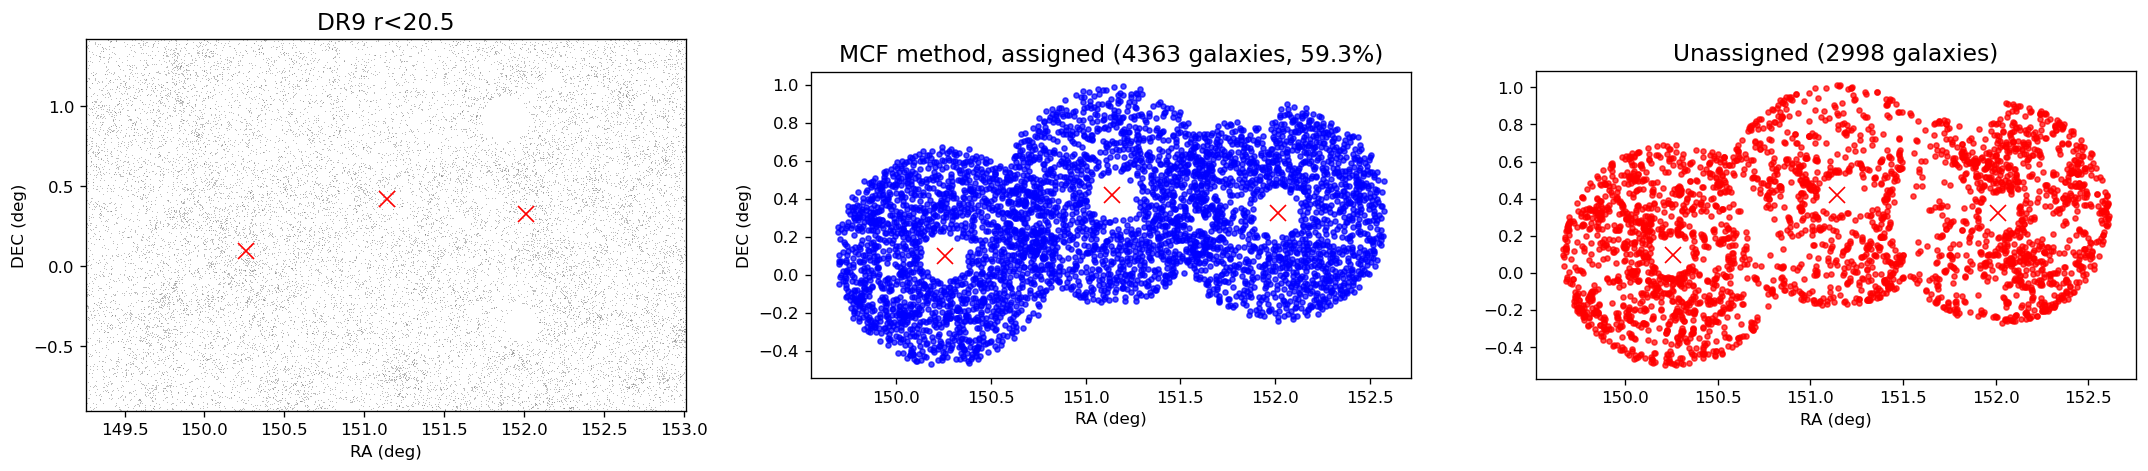

In [7]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=120)

# 1. All galaxies
axes[0].plot(gal_cat['RA'], gal_cat['DEC'], ',', alpha=0.5, color='gray')
axes[0].set_title(f'DR9 r<{rmagcut}', fontsize=14)
axes[0].set_xlabel('RA (deg)')
axes[0].set_ylabel('DEC (deg)')
axes[0].set_xlim([np.min(tiles_ra)-1.0, np.max(tiles_ra)+1.0])
axes[0].set_ylim([np.min(tiles_dec)-1.0, np.max(tiles_dec)+1.0])

# 2. Assigned galaxies
if len(gal_assigned) > 0:
    axes[1].plot(gal_assigned['RA'], gal_assigned['DEC'], '.', alpha=0.7, color='blue')
    axes[1].set_title(f'MCF method, assigned ({len(gal_assigned)} galaxies, {len(assigned_targets)/N_targets*100:.1f}%)', fontsize=14)
    axes[1].set_xlabel('RA (deg)')
    axes[1].set_ylabel('DEC (deg)')

# 3. Unassigned galaxies
if len(gal_unassigned) > 0:
    axes[2].plot(gal_unassigned['RA'], gal_unassigned['DEC'], '.', alpha=0.7, color='red')
    axes[2].set_title(f'Unassigned ({len(gal_unassigned)} galaxies)', fontsize=14)
    axes[2].set_xlabel('RA (deg)')

# Add tile centers to all plots
for ax in axes:
    ax.plot(tiles_ra, tiles_dec, 'rx', markersize=10)
    ax.set_aspect('equal')

plt.tight_layout()
ofile = f"./figs/fassign_dr9_rmag{rmagcut}_mcf_{Ntiles}tiles.png"
#plt.savefig(ofile, bbox_inches='tight')

In [8]:
gal_assigned['assigned'] = np.ones(len(gal_assigned), dtype=int)
gal_unassigned['assigned'] = np.zeros(len(gal_unassigned), dtype=int)

output = vstack((gal_assigned, gal_unassigned))
output

gal_id,RA,DEC,z,priority,assigned
int64,float64,float64,float64,float64,int64
35692560,149.75075897651217,-0.08485142242547977,0.17432260513305664,1.5172978838465894,1
35692567,149.76456149676204,-0.09825218436583408,0.11005423218011856,1.9469626038148142,1
35692570,149.76977137971437,-0.032008696792461704,0.19658000767230988,1.765459759396907,1
35692571,149.7698063433277,-0.11912417151162659,0.1658870428800583,1.2823958439671128,1
35692577,149.7778382548108,-0.10700977515531913,0.23334161937236786,1.6862220852374668,1
35692578,149.77988454295158,-0.08024537516319309,0.19790150225162506,1.1671392031000563,1
35692579,149.78108863784635,-0.12448072014239206,0.10101557523012161,1.3924424664650306,1
35692582,149.78262108341227,-0.013289172324632928,0.20223374664783478,1.6180523472528092,1
35692584,149.78591150490956,-0.08724346201148792,0.16916456818580627,1.411930094858746,1


In [9]:
odir = "./output/fba_result/"
if not os.path.exists(odir):
    os.makedirs(odir)

ofile = odir + f"fba_targets_dr9_rmag{rmagcut}_mcf_{Ntiles}tiles.fits"
output.write(ofile, overwrite=True)